# Quantum Entanglement Protocols with Qiskit

This notebook demonstrates three foundational quantum communication protocols, each powered by **quantum entanglement** — specifically shared **ebits** (entangled Bell pairs $|\Phi^+\rangle = \tfrac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$) distributed between Alice and Bob.

| Protocol | What it achieves | Resources |
|----------|-----------------|-----------|
| **Quantum Teleportation** | Transmits 1 qubit state | 1 ebit + 2 classical bits |
| **Superdense Coding** | Transmits 2 classical bits | 1 ebit + 1 qubit |
| **CHSH Game** | Proves quantum advantage over classical strategies | 1 ebit |

In [1]:
from qiskit import __version__

print(__version__)

2.2.3


## Imports

Key libraries for this notebook:
- `QuantumCircuit`, `QuantumRegister`, `ClassicalRegister` — building circuits with named registers
- `AerSimulator` — local quantum circuit simulator from `qiskit_aer`
- `plot_histogram`, `array_to_latex` — visualisation tools
- `marginal_distribution` — filters measurement results to a subset of classical bits
- `UGate` — a general single-qubit unitary parameterised by three Euler angles $(\theta, \phi, \lambda)$
- `math.pi`, `random` — for generating random gate parameters

In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

## Protocol 1 — Quantum Teleportation

**Goal**: Alice holds a qubit $Q$ in an unknown state $|\psi\rangle$ and wants to transfer that exact state to Bob's qubit using only **classical communication** — no direct qubit transmission. This is made possible by a pre-shared ebit.

The circuit uses three named quantum registers and two classical registers:

| Register | Role |
|----------|------|
| `Q` | Alice's qubit — the state to teleport |
| `A` / `B` | The shared ebit (Alice's half and Bob's half) |
| `a` / `b` | Classical bits Alice sends to Bob |

**Protocol steps:**
1. **Ebit preparation** — $H$ then CNOT on `A,B` creates $|\Phi^+\rangle = \tfrac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$
2. **Alice's encoding** — CNOT (control `Q` → target `A`), then $H$ on `Q` entangles the message into the Bell basis
3. **Alice measures** — Measures `A` → `a` and `Q` → `b`, yielding 2 classical bits
4. **Bob's correction** — Conditionally applies $X$ (if `a=1`) and $Z$ (if `b=1`) to `B`, recovering $|\psi\rangle$

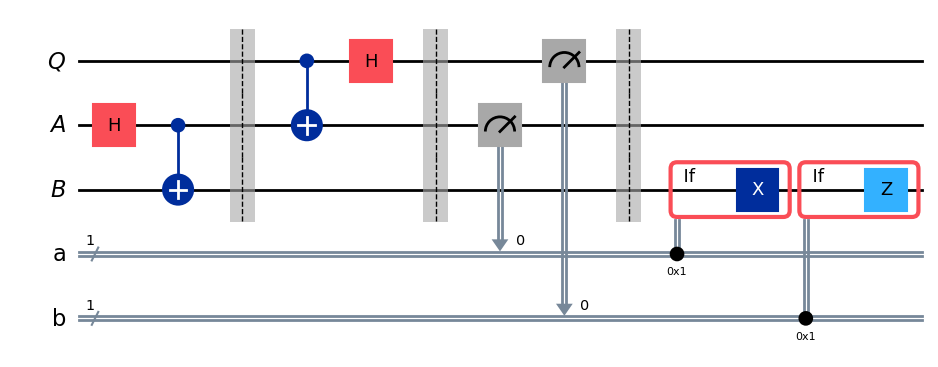

In [21]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw(output="mpl"))

### Testing Teleportation with a Random Quantum Gate

To verify the protocol works for **any** input state, we generate a random single-qubit unitary via `UGate` parameterised by three Euler angles $(\theta, \phi, \lambda)$ drawn uniformly from $[0, 2\pi)$. The resulting matrix is displayed so we can inspect it.

In [29]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

### Building the Full Verification Circuit

The test circuit wraps the teleportation protocol in a correctness check:
1. Apply the random unitary to `Q`, preparing an arbitrary state $|\psi\rangle$
2. Run the full teleportation protocol (appended via `.compose()`)
3. Apply the **inverse** of the random gate to Bob's qubit `B` — if teleportation is faithful, `B` is now $|0\rangle$
4. Measure `B` into a new `Result` register

If the `Result` bit is always `0`, teleportation succeeded for this state. Any `1` result would indicate a failure.

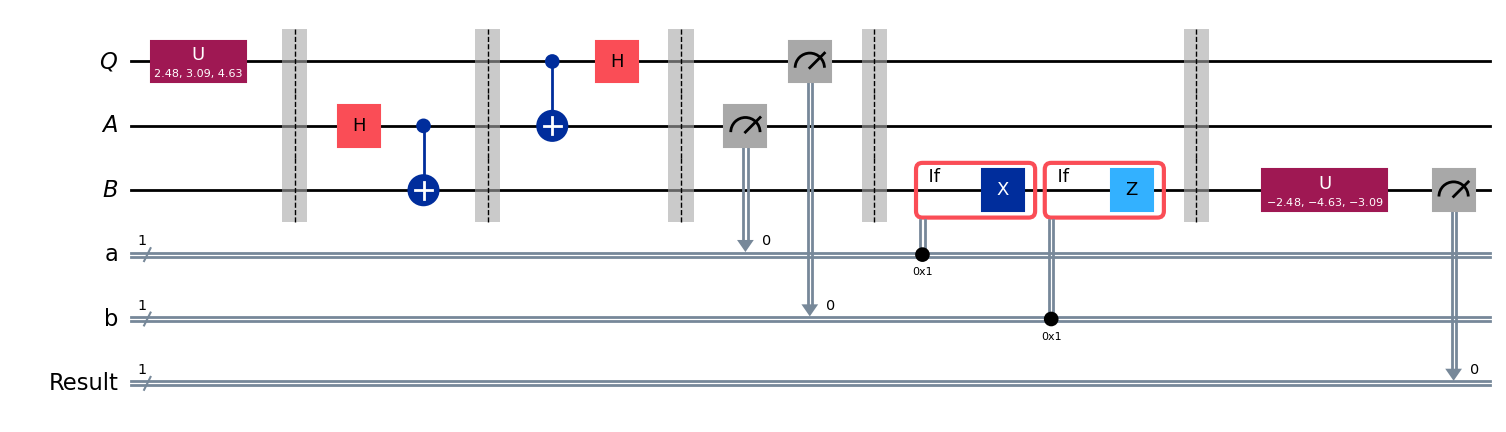

In [30]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Start with the randomly selected gate on Q

test.append(random_gate, qubit)
test.barrier()

# Append the entire teleportation protocol from above.

test = test.compose(protocol)
test.barrier()

# Finally, apply the inverse of the random unitary to B and measure.

test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw(output="mpl"))

### Simulating the Verification Circuit

`AerSimulator().run(test).result()` executes the full circuit locally. `get_counts()` returns a dictionary of all observed bitstrings across every classical register (`a`, `b`, `Result`). The histogram shows the joint distribution over all three bits.

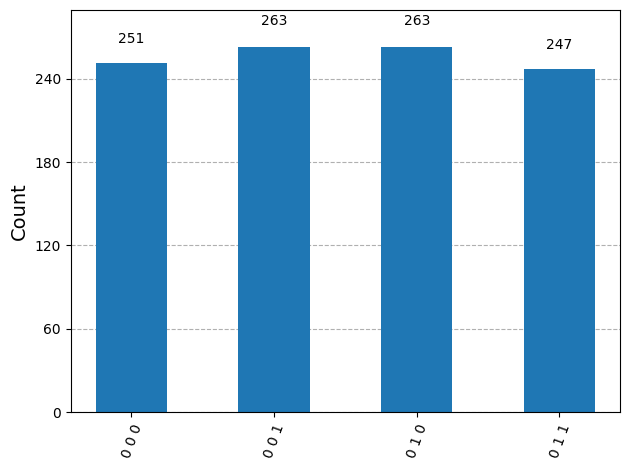

In [34]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

### Filtering to the Result Bit: Marginal Distribution

The full histogram is spread over all three classical bits. `marginal_distribution(statistics, [2])` marginalises over the intermediate bits `a` and `b`, keeping only the `Result` bit (index 2). The resulting histogram should show `0` with probability 1 — confirming that teleportation faithfully transferred the state regardless of Alice's intermediate measurement outcomes.

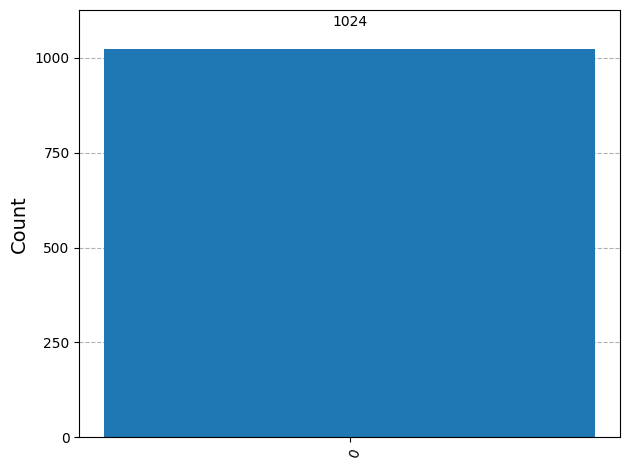

In [47]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

## Protocol 2 — Superdense Coding

**Goal**: Alice wants to send **2 classical bits** (`c` and `d`) to Bob by transmitting only **1 qubit**, leveraging a pre-shared ebit.

Superdense coding is the inverse of teleportation: where teleportation sends 1 qubit using 2 classical bits + 1 ebit, superdense coding sends 2 classical bits using 1 qubit + 1 ebit.

Alice encodes her 2-bit message by selectively applying Pauli gates to her half of the ebit, mapping each message to a distinct Bell state:

| `c` | `d` | Alice's operation | Resulting Bell state |
|-----|-----|-------------------|---------------------|
| 0 | 0 | $I$ (none) | $\lvert\Phi^+\rangle$ |
| 0 | 1 | $Z$ | $\lvert\Phi^-\rangle$ |
| 1 | 0 | $X$ | $\lvert\Psi^+\rangle$ |
| 1 | 1 | $ZX$ | $\lvert\Psi^-\rangle$ |

Bob decodes by applying CNOT then $H$, projecting back to the computational basis and reading `c` and `d`.

Here we set the two bits to transmit: `c = "0"`, `d = "1"`.

In [67]:
c = "0"
d = "1"

### Building the Superdense Coding Circuit

The circuit acts on 2 qubits (qubit 0 = Alice's half, qubit 1 = Bob's half):
1. **Ebit preparation** — $H$ + CNOT produces $|\Phi^+\rangle$
2. **Alice's encoding** — Conditionally applies $Z$ (if `d == "1"`) and/or $X$ (if `c == "1"`) to qubit 0, steering the joint state to the Bell state that encodes her 2-bit message
3. **Bob's decoding** — CNOT then $H$ disentangles the pair; measuring both qubits reveals `d` from qubit 0 and `c` from qubit 1

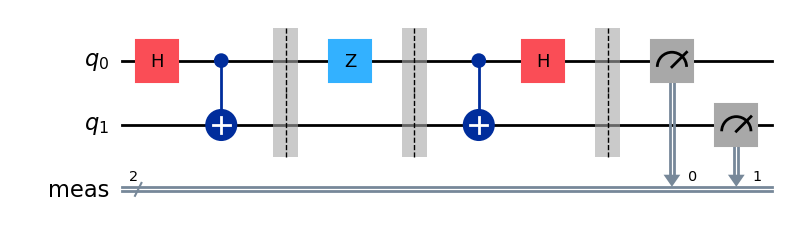

In [68]:
protocol = QuantumCircuit(2)

# Prepare ebit used for superdense coding
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

# Alice's operations
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)
protocol.barrier()

# Bob's actions
protocol.cx(0, 1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))

### Simulating the Superdense Coding Protocol

Run the circuit on `AerSimulator` and print the measured outcome. For `c = "0"`, `d = "1"`, Bob should consistently decode the bitstring `01`. The histogram should show a single outcome with frequency equal to the total shot count, confirming deterministic decoding.

Measured 01 with frequency 1024


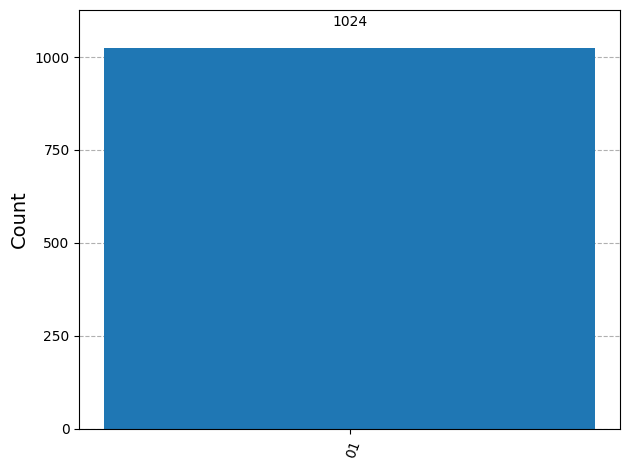

In [69]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

### Randomised Verification: Generating Alice's Bits with a Quantum Coin

To verify superdense coding works for **all four bit pairs**, we replace the hard-coded `c` and `d` with randomly generated bits. A "coin" qubit (`rbg`) is prepared in superposition ($H$) and measured twice — each measurement yields a uniformly random classical bit, producing `Alice_c` and `Alice_d`.

The circuit then runs the superdense coding protocol conditioned on those random bits, and Bob decodes them. The test confirms Bob's measurement always matches Alice's randomly chosen bits — for all four possible combinations.

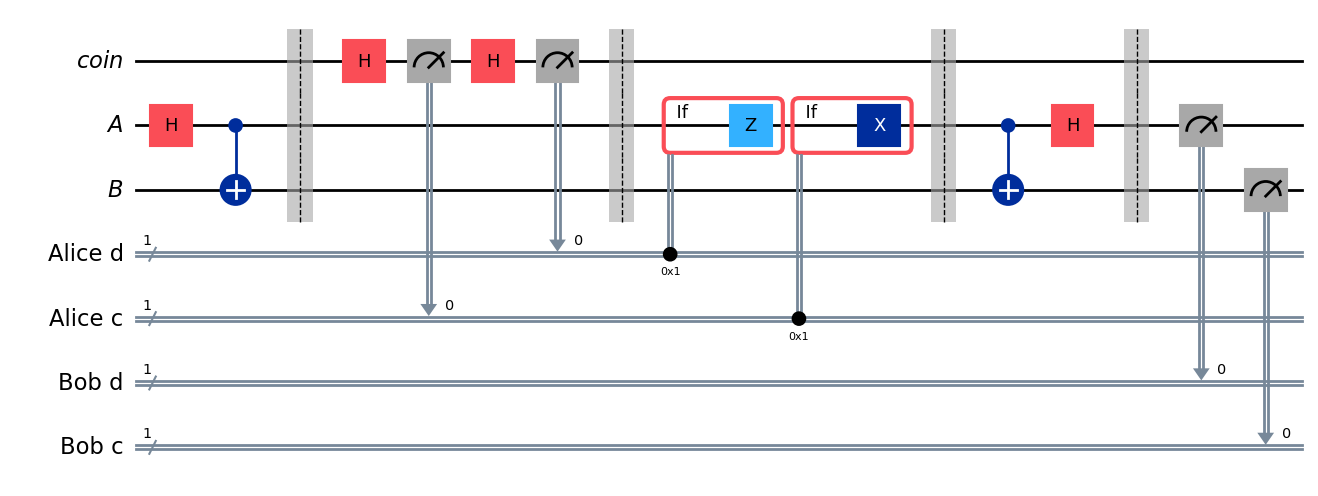

In [78]:
rbg = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# Initialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# Use the 'coin' qubit twice to generate Alice's bits c and d.
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Now the protocol runs, starting with Alice's actions, which depend
# on her bits.
with test.if_test((Alice_d, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label="X"):
    test.x(ebit0)
test.barrier()

# Bob's actions
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output="mpl"))

### Running the Randomised Verification

Simulate the randomised test circuit. The histogram should show all four outcomes (`00`, `01`, `10`, `11`) appearing with roughly equal frequency (~25% each), and in every case Bob's decoded bits should match Alice's randomly generated bits — confirming correctness across the full message space.

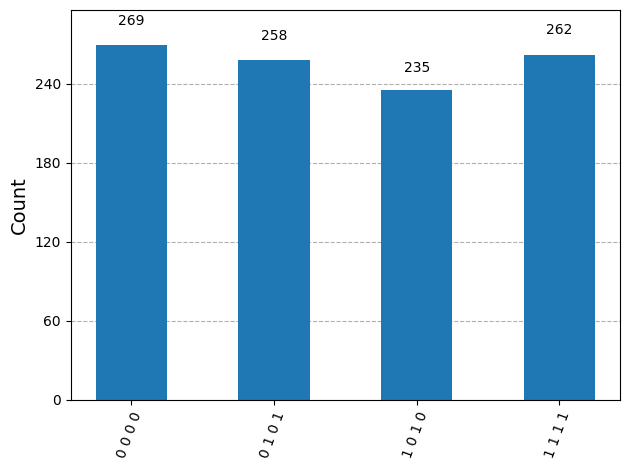

In [79]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

## Protocol 3 — The CHSH Game (Quantum Advantage)

The **CHSH game** is a two-player cooperative game that rigorously proves entanglement enables correlations impossible with any classical strategy — a direct demonstration of *quantum non-locality*.

**Setup**:
- A referee gives Alice a random bit $x$ and Bob a random bit $y$, independently
- Alice returns bit $a$, Bob returns bit $b$ — **without communicating after receiving their inputs**
- They **win** if: $a \oplus b = x \wedge y$
  - When $x = y = 1$: they must output *different* bits
  - Otherwise: they must output the *same* bit

**Bounds**:
| Strategy | Max win rate |
|----------|-------------|
| Best classical (deterministic or randomised) | $\tfrac{3}{4} = 75\%$ |
| Quantum (shared ebit + optimal rotations) | $\cos^2\!\left(\tfrac{\pi}{8}\right) \approx 85.4\%$ |

The `chsh_game(strategy)` function samples $x$ and $y$ uniformly, calls the strategy function to get $a$ and $b$, and evaluates the winning condition.

In [80]:
def chsh_game(strategy):
    # This function runs the CHSH game, using the strategy (a function
    # from two bits to two bits), returning 1 for a win and 0 for a loss.

    # Choose x and y randomly
    x, y = random.randint(0, 1), random.randint(0, 1)

    # Use the strategy to determine a and b
    a, b = strategy(x, y)

    # Decide if the strategy wins or loses
    if (a != b) == (x & y):
        return 1  # Win
    return 0  # Lose

### Quantum Strategy: Measurement Rotation Circuits

The quantum strategy uses a shared ebit and **input-dependent measurement basis rotations** ($R_y$ gates) to maximise the probability of satisfying the CHSH condition:

- **Alice** applies $R_y(0)$ (no rotation) if $x = 0$, or $R_y(-\pi/2)$ if $x = 1$, then measures
- **Bob** applies $R_y(-\pi/4)$ if $y = 0$, or $R_y(+\pi/4)$ if $y = 1$, then measures

These specific angles are derived from optimising the quantum winning probability. `chsh_circuit(x, y)` builds and returns the corresponding 2-qubit circuit for each of the four input pairs.

In [81]:
def chsh_circuit(x, y):
    # This function creates a `QuantumCircuit` implementing the quantum
    # strategy described above (including the e-bit preparation).

    qc = QuantumCircuit(2, 2)

    # Prepare an e-bit
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Alice's actions
    if x == 0:
        qc.ry(0, 0)
    else:
        qc.ry(-pi / 2, 0)
    qc.measure(0, 0)

    # Bob's actions
    if y == 0:
        qc.ry(-pi / 4, 1)
    else:
        qc.ry(pi / 4, 1)
    qc.measure(1, 1)

    return qc

### Visualising All Four Input Scenarios

Draw the CHSH circuit for each $(x, y)$ pair to confirm the $R_y$ gate angles change correctly with the inputs, while the ebit preparation remains identical in all four cases.

(x,y) = (0,0)


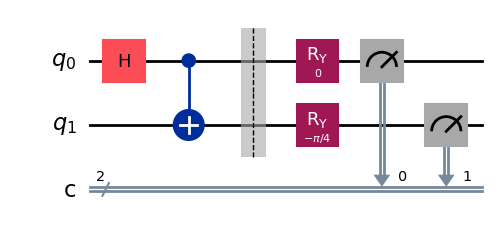

(x,y) = (0,1)


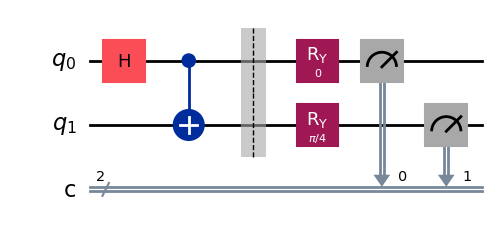

(x,y) = (1,0)


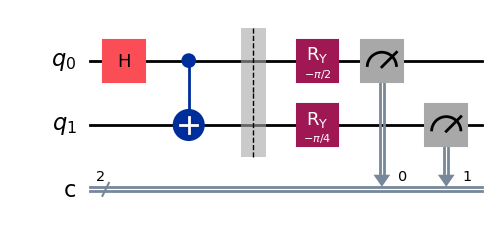

(x,y) = (1,1)


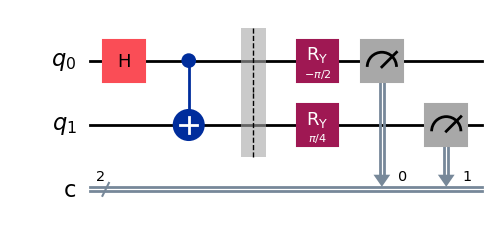

In [82]:
# Draw the four possible circuits

print("(x,y) = (0,0)")
display(chsh_circuit(0, 0).draw(output="mpl"))

print("(x,y) = (0,1)")
display(chsh_circuit(0, 1).draw(output="mpl"))

print("(x,y) = (1,0)")
display(chsh_circuit(1, 0).draw(output="mpl"))

print("(x,y) = (1,1)")
display(chsh_circuit(1, 1).draw(output="mpl"))

### Wrapping the Circuit into a Callable Strategy

`quantum_strategy(x, y)` runs the appropriate `chsh_circuit` for a single shot (`shots=1`), reads the measurement bitstring, and returns $(a, b)$ — the bits Alice and Bob report to the referee. This function matches the interface expected by `chsh_game`.

In [83]:
def quantum_strategy(x, y):
    # This function runs the appropriate quantum circuit defined above
    # one time and returns the measurement results

    # Setting `shots=1` to run the circuit once
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    # Determine the output bits and return them
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

### Benchmarking the Quantum Strategy over 5,000 Games

Run `chsh_game` 5,000 times with `quantum_strategy`. The expected win rate is $\cos^2(\pi/8) \approx 85.4\%$, clearly exceeding the classical ceiling of 75%.

In [94]:
NUM_GAMES = 5000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.8512


### Classical Strategy: Best Possible Deterministic Approach

`classical_strategy(x, y)` implements the optimal deterministic classical strategy: Alice's answer depends only on $x$, Bob's only on $y$ (no communication, no shared randomness). The best such strategy wins exactly 3 of the 4 equally likely input pairs, giving a hard upper bound of 75%.

In [91]:
def classical_strategy(x, y):
    # This function implements just one example of an optimal classical
    # strategy for the CHSH game. Other classical strategies can be
    # implemented by changing the bit values assigned to a and b.

    # Alice's answer
    if x == 0:
        a = 0
    elif x == 1:
        a = 1

    # Bob's answer
    if y == 0:
        b = 1
    elif y == 1:
        b = 0

    return a, b

### Benchmarking the Classical Strategy over 5,000 Games

Run the same `chsh_game` 5,000 times with `classical_strategy`. The win rate converges to ~75%, confirming the classical upper bound. Comparing with the quantum result (~85.4%) directly demonstrates the **quantum advantage** conferred by entanglement.

In [95]:
NUM_GAMES = 5000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(classical_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.7466
